# Regularization in Machine Learning: Ridge & Lasso

## The Problem: Overfitting & Multicollinearity

Ordinary Least Squares (OLS) minimizes the residual sum of squares:

$$\min_{\beta} \; ||y - X\beta||^2$$

When features are correlated or the number of features $p$ is close to the number of samples $n$, OLS suffers from:
- **High variance**: small changes in training data cause large coefficient swings.
- **Overfitting**: perfect training fit, poor generalization.

**Regularization** adds a penalty term to the loss function, shrinking coefficients toward zero to reduce variance at the cost of a small bias.

### General Form
$$\min_{\beta} \; \frac{1}{2n}||y - X\beta||^2 + \alpha \cdot \text{penalty}(\beta)$$

- $\alpha \geq 0$ controls regularization strength.
- **Ridge (L2)**: $\text{penalty} = \sum \beta_j^2$ — shrinks coefficients smoothly.
- **Lasso (L1)**: $\text{penalty} = \sum |\beta_j|$ — drives some coefficients exactly to zero (feature selection).
- 

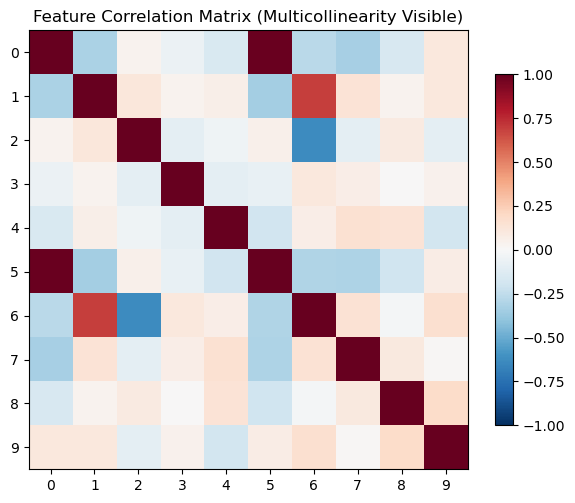

Data shape: (50, 10)
True non-zero coefficients at indices: [0 1 2 7 9]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Generate synthetic data with multicollinearity
n_samples, n_features = 50, 10
X_base = np.random.randn(n_samples, 5)

X = np.zeros((n_samples, n_features))
X[:, 0:5] = X_base
X[:, 5] = X[:, 0] + np.random.randn(n_samples) * 0.15   # correlated with feat 0
X[:, 6] = X[:, 1] - X[:, 2] + np.random.randn(n_samples) * 0.15  # linear combo
X[:, 7:10] = np.random.randn(n_samples, 3)

# True coefficients (sparse: only 4 non-zero)
true_coef = np.array([2.0, -1.5, 0.5, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, -0.5])
noise = np.random.randn(n_samples) * 2.0
y = X @ true_coef + noise

# Center data (intercept handled separately via mean centering)
X_mean = X.mean(axis=0)
y_mean = y.mean()
Xc = X - X_mean
yc = y - y_mean

# Correlation heatmap via matplotlib
corr = np.corrcoef(X.T)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))
ax.set_title('Feature Correlation Matrix (Multicollinearity Visible)')
plt.tight_layout()
plt.show()

print("Data shape:", X.shape)
print("True non-zero coefficients at indices:", np.where(true_coef != 0)[0])


## 1. Ridge Regression (L2 Penalty)

Ridge adds a squared penalty on the coefficient magnitudes:

$$\min_{\beta} \; \frac{1}{2n}||y - X\beta||^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

### Closed-Form Solution
Because the objective remains quadratic and differentiable, Ridge has an exact solution:

$$\hat{\beta}_{\text{ridge}} = (X^T X + \alpha I)^{-1} X^T y$$

### Key Properties
- **No exact zeros**: coefficients shrink proportionally but rarely hit zero.
- **Handles multicollinearity**: by inflating the diagonal of $X^T X$, it stabilizes the inverse.
- **Bayesian view**: equivalent to a Gaussian prior on $\beta$.

The plot below shows how every coefficient shrinks toward zero as $\alpha$ grows.


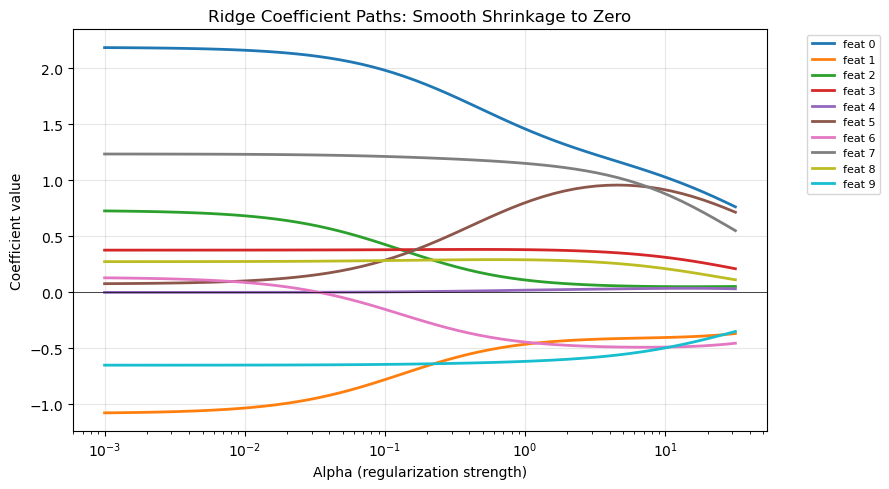

In [8]:
def ridge_closed_form(X, y, alpha):
    """Ridge regression. Assumes X and y are already centered."""
    n, p = X.shape
    I = np.eye(p)
    beta = np.linalg.inv(X.T @ X + alpha * I) @ X.T @ y
    return beta


# Coefficient paths for Ridge
alphas = np.logspace(-3, 1.5, 60)
ridge_coefs = np.zeros((len(alphas), n_features))

for i, a in enumerate(alphas):
    ridge_coefs[i] = ridge_closed_form(Xc, yc, a)

# Plot
plt.figure(figsize=(9, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_features))
for j in range(n_features):
    plt.plot(alphas, ridge_coefs[:, j], color=colors[j], linewidth=2,
             label='feat ' + str(j))
plt.xscale('log')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('Coefficient value')
plt.title('Ridge Coefficient Paths: Smooth Shrinkage to Zero')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Lasso Regression (L1 Penalty)

Lasso replaces the squared penalty with an absolute-value penalty:

$$\min_{\beta} \; \frac{1}{2n}||y - X\beta||^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

### Optimization
The L1 term is non-differentiable at zero, so there is no closed form. We use **coordinate descent**: cycle through each coefficient and apply soft-thresholding.

**Soft-thresholding operator:**
$$S(z, \gamma) = \text{sign}(z) \cdot \max(|z| - \gamma, 0)$$

Update for coordinate $j$:
$$\beta_j = \frac{S\big(\frac{1}{n}X_j^T r_j, \alpha\big)}{\frac{1}{n}||X_j||^2}$$

where $r_j = y - X\beta + \beta_j X_j$ is the partial residual.

### Key Properties
- **Sparse solutions**: some coefficients become exactly zero.
- **Feature selection**: automatically discards irrelevant predictors.
- **Bayesian view**: equivalent to a Laplace (double-exponential) prior.
- 

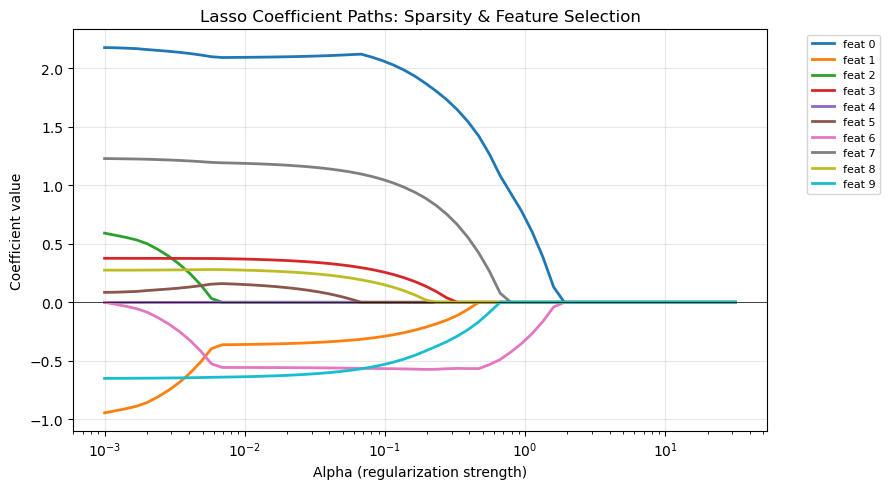

In [9]:
def lasso_coordinate_descent(X, y, alpha, max_iter=2000, tol=1e-4):
    """
    Lasso via coordinate descent.
    Objective: (1/(2n)) * ||y - Xw||^2 + alpha * ||w||_1
    """
    n, p = X.shape
    w = np.zeros(p)
    z = np.sum(X**2, axis=0) / n  # average squared norm per feature
    
    for _ in range(max_iter):
        w_old = w.copy()
        for j in range(p):
            residual = y - X @ w + w[j] * X[:, j]
            rho = np.dot(X[:, j], residual) / n
            w[j] = np.sign(rho) * max(abs(rho) - alpha, 0) / z[j]
        if np.max(np.abs(w - w_old)) < tol:
            break
    return w


# Coefficient paths for Lasso
lasso_coefs = np.zeros((len(alphas), n_features))

for i, a in enumerate(alphas):
    lasso_coefs[i] = lasso_coordinate_descent(Xc, yc, a, max_iter=3000)

# Plot
plt.figure(figsize=(9, 5))
for j in range(n_features):
    plt.plot(alphas, lasso_coefs[:, j], color=colors[j], linewidth=2,
             label='feat ' + str(j))
plt.xscale('log')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('Coefficient value')
plt.title('Lasso Coefficient Paths: Sparsity & Feature Selection')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Geometric Intuition: Why Lasso is Sparse

Regularization can be rewritten as a **constrained optimization**:

$$\min_{\beta} ||y - X\beta||^2 \quad \text{subject to} \quad \text{penalty}(\beta) \leq t$$

The solution is the first point where the RSS contour ellipses touch the constraint boundary.

- **Ridge (L2)**: constraint is a circle (or sphere). The ellipse usually hits the boundary at a smooth point, so both coefficients are non-zero.
- **Lasso (L1)**: constraint is a diamond (or cross-polytope). The ellipse often hits at a **corner**, forcing one coefficient to zero.

This explains why Lasso performs feature selection while Ridge does not.


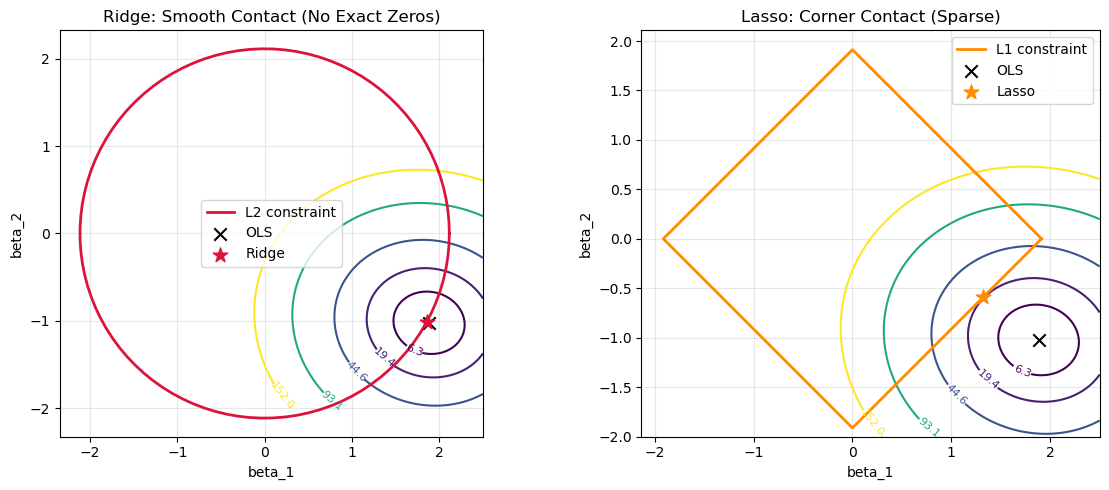

OLS:   [1.883, -1.023]
Ridge: [1.857, -1.011]
Lasso: [1.325, -0.588]


In [10]:
# 2D problem for clean geometry visualization
np.random.seed(7)
n2 = 40
X2 = np.random.randn(n2, 2)
true_w2 = np.array([2.0, -1.0])
y2 = X2 @ true_w2 + np.random.randn(n2) * 0.4

X2_mean = X2.mean(axis=0)
y2_mean = y2.mean()
X2c = X2 - X2_mean
y2c = y2 - y2_mean

beta_ols = np.linalg.lstsq(X2c, y2c, rcond=None)[0]
XtX = X2c.T @ X2c

# Grid for coefficient space
b1 = np.linspace(-0.5, 2.5, 200)
b2 = np.linspace(-2.0, 1.0, 200)
B1, B2 = np.meshgrid(b1, b2)

# RSS surface: (beta - beta_ols)^T X^T X (beta - beta_ols)
Z = np.zeros_like(B1)
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        diff = np.array([B1[i, j] - beta_ols[0], B2[i, j] - beta_ols[1]])
        Z[i, j] = diff @ XtX @ diff

# Fit Ridge and Lasso in 2D to get actual constrained solutions
alpha_geom = 0.5
beta_ridge_2d = ridge_closed_form(X2c, y2c, alpha_geom)
beta_lasso_2d = lasso_coordinate_descent(X2c, y2c, alpha_geom, max_iter=3000)

# Constraint levels matching the solution norms
t_ridge = np.sqrt(np.sum(beta_ridge_2d**2))
t_lasso = np.sum(np.abs(beta_lasso_2d))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Ridge geometry ---
ax = axes[0]
levels = np.percentile(Z, [5, 15, 30, 50, 70])
cs = ax.contour(B1, B2, Z, levels=levels, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=8)

theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(t_ridge * np.cos(theta), t_ridge * np.sin(theta),
        color='crimson', linewidth=2, label='L2 constraint')

ax.scatter(*beta_ols, color='black', s=80, zorder=5, marker='x', label='OLS')
ax.scatter(*beta_ridge_2d, color='crimson', s=120, zorder=5, marker='*', label='Ridge')

ax.set_xlabel('beta_1')
ax.set_ylabel('beta_2')
ax.set_title('Ridge: Smooth Contact (No Exact Zeros)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# --- Lasso geometry ---
ax = axes[1]
cs = ax.contour(B1, B2, Z, levels=levels, cmap='viridis')
ax.clabel(cs, inline=True, fontsize=8)

# L1 ball (diamond)
diamond_b1 = np.array([t_lasso, 0, -t_lasso, 0, t_lasso])
diamond_b2 = np.array([0, t_lasso, 0, -t_lasso, 0])
ax.plot(diamond_b1, diamond_b2, color='darkorange', linewidth=2, label='L1 constraint')

ax.scatter(*beta_ols, color='black', s=80, zorder=5, marker='x', label='OLS')
ax.scatter(*beta_lasso_2d, color='darkorange', s=120, zorder=5, marker='*', label='Lasso')

ax.set_xlabel('beta_1')
ax.set_ylabel('beta_2')
ax.set_title('Lasso: Corner Contact (Sparse)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("OLS:   [{0:.3f}, {1:.3f}]".format(*beta_ols))
print("Ridge: [{0:.3f}, {1:.3f}]".format(*beta_ridge_2d))
print("Lasso: [{0:.3f}, {1:.3f}]".format(*beta_lasso_2d))


## 4. Ridge vs Lasso: Coefficient Comparison

At a fixed regularization strength, the difference is stark:

- **Ridge** shrinks all coefficients proportionally. Correlated features share the coefficient load.
- **Lasso** pushes irrelevant coefficients exactly to zero, performing embedded feature selection.

The bar chart below compares the true data-generating coefficients against OLS, Ridge, and Lasso estimates.


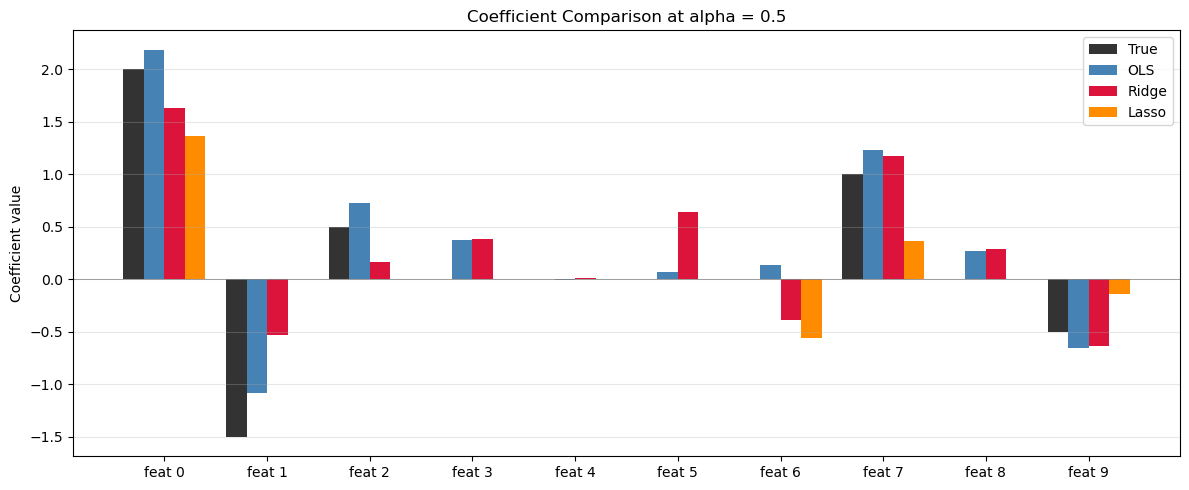

True non-zero indices:      [0 1 2 7 9]
Lasso non-zero indices:     [0 6 7 9]
Ridge non-zero indices:     [0 1 2 3 4 5 6 7 8 9]


In [11]:
alpha_compare = 0.5

beta_ols_full = np.linalg.lstsq(Xc, yc, rcond=None)[0]
beta_ridge_full = ridge_closed_form(Xc, yc, alpha_compare)
beta_lasso_full = lasso_coordinate_descent(Xc, yc, alpha_compare, max_iter=3000)

x_pos = np.arange(n_features)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - 1.5*width, true_coef, width, label='True', color='black', alpha=0.8)
ax.bar(x_pos - 0.5*width, beta_ols_full, width, label='OLS', color='steelblue')
ax.bar(x_pos + 0.5*width, beta_ridge_full, width, label='Ridge', color='crimson')
ax.bar(x_pos + 1.5*width, beta_lasso_full, width, label='Lasso', color='darkorange')

ax.set_xticks(x_pos)
ax.set_xticklabels(['feat ' + str(i) for i in range(n_features)])
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Comparison at alpha = ' + str(alpha_compare))
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("True non-zero indices:     ", np.where(true_coef != 0)[0])
print("Lasso non-zero indices:    ", np.where(np.abs(beta_lasso_full) > 1e-4)[0])
print("Ridge non-zero indices:    ", np.where(np.abs(beta_ridge_full) > 1e-4)[0])


## 5. The Bias-Variance Tradeoff

Regularization introduces **bias** (systematic error) to reduce **variance** (sensitivity to training noise).

| Alpha | Effect | Train Error | Validation Error |
|-------|--------|-------------|------------------|
| Very small | Near-OLS | Low | High (overfitting) |
| Optimal | Balanced | Moderate | Lowest |
| Very large | Heavy shrinkage | High | High (underfitting) |

The curves below show training and validation MSE as a function of alpha. The U-shaped validation curve is the classic signature of the bias-variance tradeoff.


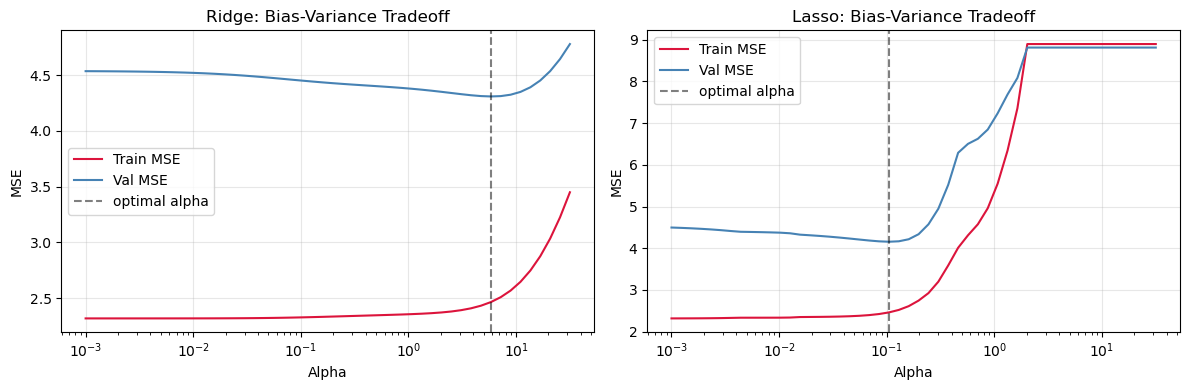

Best Ridge alpha: 5.8251
Best Lasso alpha: 0.1048


In [12]:
# Train/validation split
split = int(0.7 * n_samples)
X_train, X_val = Xc[:split], Xc[split:]
y_train, y_val = yc[:split], yc[split:]

alphas_bv = np.logspace(-3, 1.5, 50)

train_mse_ridge, val_mse_ridge = [], []
train_mse_lasso, val_mse_lasso = [], []

for a in alphas_bv:
    # Ridge
    br = ridge_closed_form(X_train, y_train, a)
    train_mse_ridge.append(np.mean((X_train @ br - y_train)**2))
    val_mse_ridge.append(np.mean((X_val @ br - y_val)**2))
    
    # Lasso
    bl = lasso_coordinate_descent(X_train, y_train, a, max_iter=3000)
    train_mse_lasso.append(np.mean((X_train @ bl - y_train)**2))
    val_mse_lasso.append(np.mean((X_val @ bl - y_val)**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(alphas_bv, train_mse_ridge, color='crimson', label='Train MSE')
axes[0].plot(alphas_bv, val_mse_ridge, color='steelblue', label='Val MSE')
axes[0].axvline(alphas_bv[np.argmin(val_mse_ridge)], color='black', linestyle='--', alpha=0.5, label='optimal alpha')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('MSE')
axes[0].set_title('Ridge: Bias-Variance Tradeoff')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas_bv, train_mse_lasso, color='crimson', label='Train MSE')
axes[1].plot(alphas_bv, val_mse_lasso, color='steelblue', label='Val MSE')
axes[1].axvline(alphas_bv[np.argmin(val_mse_lasso)], color='black', linestyle='--', alpha=0.5, label='optimal alpha')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('MSE')
axes[1].set_title('Lasso: Bias-Variance Tradeoff')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_alpha_ridge = alphas_bv[np.argmin(val_mse_ridge)]
best_alpha_lasso = alphas_bv[np.argmin(val_mse_lasso)]
print("Best Ridge alpha: {0:.4f}".format(best_alpha_ridge))
print("Best Lasso alpha: {0:.4f}".format(best_alpha_lasso))


## 6. Elastic Net: The Best of Both Worlds

When features are highly correlated, Lasso tends to pick one and ignore the rest arbitrarily. **Elastic Net** combines both penalties:

$$\min_{\beta} \; \frac{1}{2n}||y - X\beta||^2 + \alpha \cdot \text{l1\_ratio} \cdot \sum |\beta_j| + \alpha \cdot \frac{1 - \text{l1\_ratio}}{2} \sum \beta_j^2$$

- **l1_ratio = 1.0**: Pure Lasso
- **l1_ratio = 0.0**: Pure Ridge
- **0 < l1_ratio < 1**: Interpolates between them

Elastic Net enjoys the grouping effect: correlated features receive similar non-zero coefficients, while still performing shrinkage and selection.


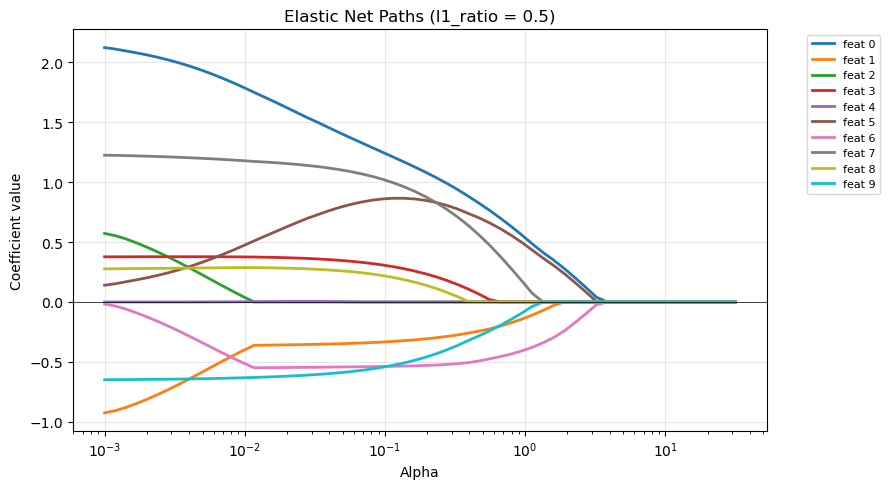

Non-zero counts at alpha = 0.5:
  Ridge:       10
  Lasso:       4
  ElasticNet:  7


In [13]:
def elastic_net_cd(X, y, alpha, l1_ratio, max_iter=2000, tol=1e-4):
    """
    Elastic Net via coordinate descent.
    Objective: (1/(2n))||y - Xw||^2 + alpha*l1_ratio*||w||_1 + alpha*(1-l1_ratio)/2 * ||w||_2^2
    """
    n, p = X.shape
    w = np.zeros(p)
    z = np.sum(X**2, axis=0) / n
    
    for _ in range(max_iter):
        w_old = w.copy()
        for j in range(p):
            residual = y - X @ w + w[j] * X[:, j]
            rho = np.dot(X[:, j], residual) / n
            denom = z[j] + alpha * (1 - l1_ratio)
            numer = np.sign(rho) * max(abs(rho) - alpha * l1_ratio, 0)
            w[j] = numer / denom
        if np.max(np.abs(w - w_old)) < tol:
            break
    return w


# Elastic Net paths
l1_ratio = 0.5
enet_coefs = np.zeros((len(alphas), n_features))
for i, a in enumerate(alphas):
    enet_coefs[i] = elastic_net_cd(Xc, yc, a, l1_ratio, max_iter=3000)

plt.figure(figsize=(9, 5))
for j in range(n_features):
    plt.plot(alphas, enet_coefs[:, j], color=colors[j], linewidth=2,
             label='feat ' + str(j))
plt.xscale('log')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Alpha')
plt.ylabel('Coefficient value')
plt.title('Elastic Net Paths (l1_ratio = ' + str(l1_ratio) + ')')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare sparsity patterns at a fixed alpha
a_fixed = 0.5
ridge_fixed = ridge_closed_form(Xc, yc, a_fixed)
lasso_fixed = lasso_coordinate_descent(Xc, yc, a_fixed, max_iter=3000)
enet_fixed = elastic_net_cd(Xc, yc, a_fixed, l1_ratio, max_iter=3000)

print("Non-zero counts at alpha = {0}:".format(a_fixed))
print("  Ridge:      ", np.sum(np.abs(ridge_fixed) > 1e-4))
print("  Lasso:      ", np.sum(np.abs(lasso_fixed) > 1e-4))
print("  ElasticNet: ", np.sum(np.abs(enet_fixed) > 1e-4))


## Summary

| Property | OLS | Ridge (L2) | Lasso (L1) | Elastic Net |
|----------|-----|------------|------------|-------------|
| **Closed Form** | Yes | Yes | No | No |
| **Sparse Solution** | No | No | Yes | Yes |
| **Feature Selection** | No | No | Yes | Yes |
| **Handles Multicollinearity** | Poor | Excellent | Moderate | Excellent |
| **Grouping Effect** | No | Yes | No | Yes |
| **Key Hyperparameter** | None | Alpha | Alpha | Alpha + l1_ratio |

### Key Takeaways
- Use **Ridge** when you believe most features contribute slightly (shrinkage, no selection).
- Use **Lasso** when you suspect only a few features matter (sparse ground truth).
- Use **Elastic Net** when features are correlated and you want both grouping and selection.
- Always tune alpha via cross-validation on a validation curve like those shown above.
- 